In [ ]:
import pandas as pd  
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Data Wrangling

In this notebook we will review the data scraped in the `data_scraping.ipynb` notebook and perform wrangling to produce dataset that can be readily used in other notebooks.

## Data Review

In [4]:
# loading data

raw_data = pd.read_csv('../data/uefa_results.csv')
raw_data.head()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
0,1969/70,CL,Qualifying Round,TPS Turku,Fin,KB København,Den,0-1,0-4,0-5,no,no
1,1969/70,CL,Round 1,Leeds United,Eng,Lyn Oslo,Nor,10-0,6-0,16-0,no,no
2,1969/70,CL,Round 1,CSKA Sofia,Bul,Ferencváros,Hun,2-1,1-4,3-5,no,no
3,1969/70,CL,Round 1,Standard Liège,Bel,17 Nëntori Tirana,Alb,3-0,1-1,4-1,no,no
4,1969/70,CL,Round 1,Real Madrid,Esp,Olympiakos Nicosia,Cyp,8-0,6-1,14-1,no,no


In [3]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 13872 entries, 0 to 13871
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   season           13872 non-null  str  
 1   competition      13872 non-null  str  
 2   round            13872 non-null  str  
 3   team_a           13872 non-null  str  
 4   country_a        13872 non-null  str  
 5   team_b           13872 non-null  str  
 6   country_b        13872 non-null  str  
 7   score_leg1       13872 non-null  str  
 8   score_leg2       12303 non-null  str  
 9   score_aggregate  13872 non-null  str  
 10  extra_time       13872 non-null  str  
 11  penalties        13872 non-null  str  
dtypes: str(12)
memory usage: 1.3 MB


In [4]:
raw_data.nunique()

season               57
competition           5
round                20
team_a             1070
country_a            59
team_b             1017
country_b            59
score_leg1           67
score_leg2           72
score_aggregate     147
extra_time            1
penalties             1
dtype: int64

In [5]:
raw_data[raw_data['round'] == 'Final'][:10]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
31,1969/70,CL,Final,Feyenoord,Ned,Celtic,Sco,2-1,NaN,2-1,no,no
63,1969/70,CW,Final,Manchester City,Eng,Górnik Zabrze,Pol,2-1,NaN,2-1,no,no
126,1969/70,INTER-CITIES FAIRS CUP,Final,Anderlecht,Bel,Arsenal,Eng,3-1,0-3,3-4,no,no
158,1970/71,CL,Final,Ajax,Ned,Panathinaikos,Gre,2-0,NaN,2-0,no,no
191,1970/71,CW,Final,Chelsea,Eng,Real Madrid,Esp,1-1,NaN,1-1,no,no
254,1970/71,INTER-CITIES FAIRS CUP,Final,Juventus,Ita,Leeds United,Eng,2-2,1-1,3-3,no,no
286,1971/72,CL,Final,Ajax,Ned,Internazionale,Ita,2-0,NaN,2-0,no,no
319,1971/72,CW,Final,Glasgow Rangers,Sco,Dinamo Moscow,URS,3-2,NaN,3-2,no,no
381,1971/72,EL,Final,Wolverhampton Wanderers,Eng,Tottenham Hotspur,Eng,1-2,1-1,2-3,no,no
410,1972/73,CL,Final,Ajax,Ned,Juventus,Ita,1-0,NaN,1-0,no,no


In [6]:
raw_data[raw_data['score_leg2'].isna()]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
31,1969/70,CL,Final,Feyenoord,Ned,Celtic,Sco,2-1,NaN,2-1,no,no
63,1969/70,CW,Final,Manchester City,Eng,Górnik Zabrze,Pol,2-1,NaN,2-1,no,no
158,1970/71,CL,Final,Ajax,Ned,Panathinaikos,Gre,2-0,NaN,2-0,no,no
191,1970/71,CW,Final,Chelsea,Eng,Real Madrid,Esp,1-1,NaN,1-1,no,no
286,1971/72,CL,Final,Ajax,Ned,Internazionale,Ita,2-0,NaN,2-0,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...
13867,2025/26,CO,Round of 16,Fiorentina,Ita,Raków Czestochowa,Pol,2-1,NaN,2-1,no,no
13868,2025/26,CO,Round of 16,Samsunspor,Tur,Rayo Vallecano,Esp,1-3,NaN,1-3,no,no
13869,2025/26,CO,Round of 16,NK Celje,Slo,AEK Athens,Gre,0-4,NaN,0-4,no,no
13870,2025/26,CO,Round of 16,Sigma Olomouc,Cze,FSV Mainz 05,Ger,0-0,NaN,0-0,no,no


In [7]:
raw_data.tail()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
13867,2025/26,CO,Round of 16,Fiorentina,Ita,Raków Czestochowa,Pol,2-1,NaN,2-1,no,no
13868,2025/26,CO,Round of 16,Samsunspor,Tur,Rayo Vallecano,Esp,1-3,NaN,1-3,no,no
13869,2025/26,CO,Round of 16,NK Celje,Slo,AEK Athens,Gre,0-4,NaN,0-4,no,no
13870,2025/26,CO,Round of 16,Sigma Olomouc,Cze,FSV Mainz 05,Ger,0-0,NaN,0-0,no,no
13871,2025/26,CO,Round of 16,NK Rijeka,Cro,RC Strasbourg,Fra,1-2,NaN,1-2,no,no


In [8]:
raw_data['score_leg2'] = raw_data['score_leg2'].fillna('No Match')
raw_data['score_leg2'].head()

0    0-4
1    6-0
2    1-4
3    1-1
4    6-1
Name: score_leg2, dtype: str

In [9]:
raw_data['round'].unique()

<StringArray>
[                'Qualifying Round',                          'Round 1',
                          'Round 2',                   'Quarter Finals',
                      'Semi Finals',                            'Final',
                          'Round 3',                      'Group Stage',
             '1st Qualifying Round',             '2nd Qualifying Round',
             '3rd Qualifying Round',                  '1st Group Stage',
                  '2nd Group Stage',                          'Round 4',
 '4th Qualifying or Play-off Round',        'Qualifying Play-off Round',
                'Preliminary Round',                      'Round of 16',
         'Knockout round play-offs',                     'League Stage']
Length: 20, dtype: str

## Get info functions

Functions to query the raw dataset to sum up useful information

### `get_team_stats`

In [10]:
def get_team_stats(raw_data: pd.DataFrame, team: str) -> dict:
    """
    Compute aggregate statistics for a team.
    
    Each match leg (score_leg1, score_leg2) is treated as a separate game.
    
    Args:
        raw_data: DataFrame with columns ['season', 'team_a', 'team_b', 'score_leg1', 'score_leg2']
        team: Team name to compute stats for (string)
    
    Returns:
        Dictionary with keys:
            - 'seasons': List of seasons the team played (sorted)
            - 'total_seasons': Total number of unique seasons the team played
            - 'total_games': Total number of games (individual legs)
            - 'total_wins': Total number of wins across all games
            - 'total_draws': Total number of draws
            - 'total_losses': Total number of losses
            - 'total_goals_for': Total goals scored by the team
            - 'total_goals_against': Total goals conceded by the team
    """
    
    def parse_score(score_str: str):
        """Parse score string like '3-0' into tuple (goals_for, goals_against)."""
        if pd.isna(score_str) or score_str == 'No Match':
            return None
        try:
            parts = str(score_str).split('-')
            if len(parts) == 2:
                return (int(parts[0]), int(parts[1]))
        except (ValueError, AttributeError):
            pass
        return None
    
    # Filter matches where team is either team_a or team_b
    team_matches = raw_data[
        (raw_data['team_a'] == team) | (raw_data['team_b'] == team)
    ].copy()
    
    # Track seasons
    seasons_set = set(team_matches['season'].unique())
    seasons_list = sorted(list(seasons_set))
    
    # Compute total seasons
    total_seasons = team_matches['season'].nunique()
    
    # Initialize counters
    total_games = 0
    total_wins = 0
    total_draws = 0
    total_losses = 0
    total_goals_for = 0
    total_goals_against = 0
    
    for idx, row in team_matches.iterrows():
        # Process leg 1
        score_leg1 = parse_score(row['score_leg1'])
        if score_leg1 is not None:
            total_games += 1
            if row['team_a'] == team:
                goals_for, goals_against = score_leg1
            else:  # team is team_b
                goals_against, goals_for = score_leg1
            
            total_goals_for += goals_for
            total_goals_against += goals_against
            
            if goals_for > goals_against:
                total_wins += 1
            elif goals_for == goals_against:
                total_draws += 1
            else:
                total_losses += 1
        
        # Process leg 2
        score_leg2 = parse_score(row['score_leg2'])
        if score_leg2 is not None:
            total_games += 1
            if row['team_a'] == team:
                goals_for, goals_against = score_leg2
            else:  # team is team_b
                goals_against, goals_for = score_leg2
            
            total_goals_for += goals_for
            total_goals_against += goals_against
            
            if goals_for > goals_against:
                total_wins += 1
            elif goals_for == goals_against:
                total_draws += 1
            else:
                total_losses += 1
    
    return {
        'seasons': seasons_list,
        'total_seasons': total_seasons,
        'total_games': total_games,
        'total_wins': total_wins,
        'total_draws': total_draws,
        'total_losses': total_losses,
        'total_goals_for': total_goals_for,
        'total_goals_against': total_goals_against
    }

In [11]:
# Test the function with a few examples
# example_teams = ['Real Madrid', 'Juventus', 'Napoli']
# for team_name in example_teams:
#     stats = get_team_stats(raw_data, team_name)
#     print(f"\n{team_name}:")
#     print(f"  Seasons played: {stats['seasons']}")
#     print(f"  Total seasons: {stats['total_seasons']}")
#     print(f"  Total games: {stats['total_games']}")
#     print(f"  Total wins: {stats['total_wins']}")
#     print(f"  Total draws: {stats['total_draws']}")
#     print(f"  Total losses: {stats['total_losses']}")
#     print(f"  Total goals for: {stats['total_goals_for']}")
#     print(f"  Total goals against: {stats['total_goals_against']}")

### `get_countries_seasons_details`

In [12]:
def get_countries_seasons_details(raw_data: pd.DataFrame, season: list, country: list) -> pd.DataFrame:
    """Get all matches involving specific country/countries in a specific season/seasons."""
    return raw_data[
        (raw_data['season'].isin(season)) & 
        ((raw_data['country_a'].isin(country)) | (raw_data['country_b'].isin(country)))
    ]

### `get_team_matches`

In [13]:
def get_team_matches(raw_data: pd.DataFrame, season: list, team: str) -> pd.DataFrame:
    """Get all matches involving a specific team in a specific season/seasons."""
    if season == []:
        return raw_data[(raw_data['team_a'] == team) | (raw_data['team_b'] == team)]
    return raw_data[
        (raw_data['season'].isin(season)) & 
        ((raw_data['team_a'] == team) | (raw_data['team_b'] == team))
    ]

In [14]:
get_team_matches(raw_data, season = ['2007/08', '2009/10'], team='Slaven Koprivnica')

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
6560,2007/08,EL,1st Qualifying Round,Slaven Koprivnica,Cro,Teuta Durrës,Alb,6-2,2-2,8-4,no,no
6593,2007/08,EL,2nd Qualifying Round,Slaven Koprivnica,Cro,Galatasaray,Tur,1-2,1-2,2-4,no,no
7194,2009/10,EL,1st Qualifying Round,Slaven Koprivnica,Cro,Birkirkara,Mlt,1-0,0-0,1-0,no,no
7230,2009/10,EL,2nd Qualifying Round,Milano Kumanovo,Mac,Slaven Koprivnica,Cro,0-4,2-8,2-12,no,no
7264,2009/10,EL,3rd Qualifying Round,Tromsø IL,Nor,Slaven Koprivnica,Cro,2-1,2-0,4-1,no,no


### `country_season_stats`

In [15]:
def country_season_stats(df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-country season stats for every team from that country.

    Each match leg (`score_leg1`, `score_leg2`) is treated as a separate game.
    Each team contributes stats for its country (so foreign opponents are included).

    Returns a DataFrame with columns:
      - country
      - season
      - num_teams: Number of unique teams from that country that played in that season
      - wins
      - draws
      - losses
      - goals_for
      - goals_against

    For countries that did not participate in a season, all numerical columns are filled with 0.

    Args:
        df: Raw data frame with columns ['season', 'team_a', 'team_b', 'country_a', 'country_b', 'score_leg1', 'score_leg2'].
    """

    def _parse_score(score: str):
        if pd.isna(score):
            return None, None
        parts = str(score).split("-")
        if len(parts) != 2:
            return None, None
        try:
            return int(parts[0].strip()), int(parts[1].strip())
        except ValueError:
            return None, None

    def _expand_leg(df_leg: pd.DataFrame, score_col: str, team_col: str, opp_col: str, country_col: str, reverse_score: bool = False):
        tmp = df_leg[["season", team_col, opp_col, country_col, score_col]].copy()
        tmp = tmp.rename(columns={
            team_col: "team",
            opp_col: "opp",
            country_col: "country",
            score_col: "score",
        })

        parsed = tmp["score"].apply(_parse_score).tolist()
        if reverse_score:
            # For away team: goals_for is the second number, goals_against is the first
            tmp[["goals_against", "goals_for"]] = pd.DataFrame(parsed, index=tmp.index)
        else:
            # For home team: goals_for is the first number, goals_against is the second
            tmp[["goals_for", "goals_against"]] = pd.DataFrame(parsed, index=tmp.index)

        # Determine result from the perspective of `team`
        tmp["result"] = np.where(
            tmp["goals_for"] > tmp["goals_against"],
            "W",
            np.where(tmp["goals_for"] < tmp["goals_against"], "L", "D"),
        )

        return tmp.drop(columns=["score", "opp"])

    # Expand all 4 combinations: both teams in both legs
    # Leg 1: score_leg1 = team_a_goals - team_b_goals
    leg1_team_a = _expand_leg(df, "score_leg1", "team_a", "team_b", "country_a", reverse_score=False)
    leg1_team_b = _expand_leg(df, "score_leg1", "team_b", "team_a", "country_b", reverse_score=True)
    
    # Leg 2: score_leg2 = team_a_goals - team_b_goals (same format as leg1)
    leg2_team_a = _expand_leg(df, "score_leg2", "team_a", "team_b", "country_a", reverse_score=False)
    leg2_team_b = _expand_leg(df, "score_leg2", "team_b", "team_a", "country_b", reverse_score=True)

    matches = pd.concat([leg1_team_a, leg1_team_b, leg2_team_a, leg2_team_b], ignore_index=True, sort=False)

    matches = matches.dropna(subset=["goals_for", "goals_against"])

    stats = (
        matches.groupby(["country", "season"])
        .agg(
            num_teams=("team", "nunique"),
            wins=("result", lambda s: (s == "W").sum()),
            draws=("result", lambda s: (s == "D").sum()),
            losses=("result", lambda s: (s == "L").sum()),
            goals_for=("goals_for", "sum"),
            goals_against=("goals_against", "sum"),
        )
        .reset_index()
    )

    # Create a complete index with all country-season combinations
    all_countries = stats["country"].unique()
    all_seasons = stats["season"].unique()
    complete_index = pd.MultiIndex.from_product(
        [sorted(all_countries), sorted(all_seasons)],
        names=["country", "season"]
    )
    
    # Reindex to include all combinations, filling missing ones with 0
    stats = stats.set_index(["country", "season"]).reindex(complete_index, fill_value=0).reset_index()

    return stats

# Example usage:
country_stats = country_season_stats(raw_data)
country_stats.head()


,country,season,num_teams,wins,draws,losses,goals_for,goals_against
0,Alb,1969/70,1,0,1,1,1.0,4.0
1,Alb,1970/71,2,1,2,3,8.0,10.0
2,Alb,1971/72,2,0,1,3,1.0,6.0
3,Alb,1972/73,1,0,3,1,3.0,9.0
4,Alb,1973/74,0,0,0,0,0.0,0.0


### Highest round for each country in season

Implementing a function to retrieve the highest round reached, in which competition, by country in each season.

- input: raw_data dataframe
- output: dataframe

In [16]:
raw_data.columns

Index(['season', 'competition', 'round', 'team_a', 'country_a', 'team_b',
       'country_b', 'score_leg1', 'score_leg2', 'score_aggregate',
       'extra_time', 'penalties'],
      dtype='str')

In [17]:
def get_country_season_highest_round(raw_data: pd.DataFrame) -> pd.DataFrame:
    """
    For each season and each country assign the highest stage reached by any team
    from that country and list competitions where that highest stage was reached.
    """
    stage_group = {
        "qualifying round",
        "4th qualifying or play-off round",
        "qualifying play-off round",
        "preliminary round",
        "round 1",
        "round 2",
        "round 3",
        "round 4",
        "1st qualifying round",
        "2nd qualifying round",
        "3rd qualifying round",
        "group stage",
        "1st group stage",
        "2nd group stage",
        "knockout round play-offs",
        "league stage",
    }

    def normalize_round(rnd):
        if pd.isna(rnd):
            return None
        r = str(rnd).strip()
        if not r:
            return None
        key = r.lower()
        if key in stage_group:
            return "stage"
        if "round of 16" in key:
            return "Round of 16"
        if "quarter" in key:
            return "Quarter Finals"
        if "semi" in key:
            return "Semi Finals"
        if key == "final" or "final" in key:
            # final may appear as "Final" or "Finals"
            return "Final"
        # fallback for unknown or other early/qualifiers
        return "stage"

    rank_map = {"stage": 1, "Round of 16": 2, "Quarter Finals": 3, "Semi Finals": 4, "Final": 5}
    rank_to_round = {v: k for k, v in rank_map.items()}

    df_a = raw_data[["season", "country_a", "competition", "round"]].rename(
        columns={"country_a": "country"}
    )
    df_b = raw_data[["season", "country_b", "competition", "round"]].rename(
        columns={"country_b": "country"}
    )
    stacked = pd.concat([df_a, df_b], ignore_index=True, sort=False)
    stacked["stage"] = stacked["round"].apply(normalize_round)
    stacked = stacked.dropna(subset=["country", "stage"])

    stacked["stage_rank"] = stacked["stage"].map(rank_map).fillna(1).astype(int)

    stats = stacked.groupby(["season", "country"]).agg(max_rank=("stage_rank", "max")).reset_index()

    best_comps = (
        stacked.loc[
            stacked.groupby(["season", "country"])["stage_rank"].transform("max")
            == stacked["stage_rank"]
        ]
        .groupby(["season", "country"])["competition"]
        .agg(lambda x: sorted(list(set(x))))
        .reset_index()
    )

    result = stats.merge(best_comps, on=["season", "country"], how="left")
    result["highest round"] = result["max_rank"].map(rank_to_round)
    result = result[["season", "country", "highest round", "competition"]]

    all_seasons = sorted(raw_data["season"].dropna().unique())
    all_countries = sorted(
        pd.unique(
            pd.concat(
                [raw_data["country_a"].dropna(), raw_data["country_b"].dropna()], ignore_index=True
            )
        )
    )

    full_index = pd.MultiIndex.from_product([all_seasons, all_countries], names=["season", "country"])
    result_full = pd.DataFrame(index=full_index).reset_index().merge(result, on=["season", "country"], how="left")

    result_full["highest round"] = result_full["highest round"].fillna("not partecipate")
    
    def _ensure_flat_list(x):
        """Ensure competition column contains flat lists, not nested."""
        if x is None or (isinstance(x, float) and pd.isna(x)):
            return []
        if isinstance(x, list):
            # If it's a list of lists, flatten it
            if x and isinstance(x[0], list):
                return [item for sublist in x for item in sublist]
            return x
        if isinstance(x, np.ndarray):
            return list(x)
        return []
    
    result_full["competition"] = result_full["competition"].apply(_ensure_flat_list)

    return result_full

In [18]:
raw_data.head()

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
0,1969/70,CL,Qualifying Round,TPS Turku,Fin,KB København,Den,0-1,0-4,0-5,no,no
1,1969/70,CL,Round 1,Leeds United,Eng,Lyn Oslo,Nor,10-0,6-0,16-0,no,no
2,1969/70,CL,Round 1,CSKA Sofia,Bul,Ferencváros,Hun,2-1,1-4,3-5,no,no
3,1969/70,CL,Round 1,Standard Liège,Bel,17 Nëntori Tirana,Alb,3-0,1-1,4-1,no,no
4,1969/70,CL,Round 1,Real Madrid,Esp,Olympiakos Nicosia,Cyp,8-0,6-1,14-1,no,no


In [19]:
# Example usage
country_season_highest = get_country_season_highest_round(raw_data)
country_season_highest.head(10)

,season,country,highest round,competition
0,1969/70,Alb,stage,[CL]
1,1969/70,And,not partecipate,[]
2,1969/70,Arm,not partecipate,[]
3,1969/70,Aut,stage,"[CL, CW, INTER-CITIES FAIRS CUP]"
4,1969/70,Azb,not partecipate,[]
5,1969/70,Bel,Final,[INTER-CITIES FAIRS CUP]
6,1969/70,Bls,not partecipate,[]
7,1969/70,Bos,not partecipate,[]
8,1969/70,Bul,Quarter Finals,[CW]
9,1969/70,Cro,not partecipate,[]


In [20]:
# Debug: Check what's happening in the function
import pandas as pd

raw_data = pd.read_csv('../data/uefa_results.csv')

# Quick test of the best_comps/result merge
stage_group = {
    "qualifying round", "4th qualifying or play-off round", "qualifying play-off round",
    "preliminary round", "round 1", "round 2", "round 3", "round 4",
    "1st qualifying round", "2nd qualifying round", "3rd qualifying round",
    "group stage", "1st group stage", "2nd group stage", "knockout round play-offs", "league stage",
}

def normalize_round(rnd):
    if pd.isna(rnd):
        return None
    r = str(rnd).strip()
    if not r:
        return None
    key = r.lower()
    if key in stage_group:
        return "stage"
    if "round of 16" in key:
        return "Round of 16"
    if "quarter" in key:
        return "Quarter Finals"
    if "semi" in key:
        return "Semi Finals"
    if key == "final" or "final" in key:
        return "Final"
    return "stage"

rank_map = {"stage": 1, "Round of 16": 2, "Quarter Finals": 3, "Semi Finals": 4, "Final": 5}
rank_to_round = {v: k for k, v in rank_map.items()}

df_a = raw_data[["season", "country_a", "competition", "round"]].rename(columns={"country_a": "country"})
df_b = raw_data[["season", "country_b", "competition", "round"]].rename(columns={"country_b": "country"})
stacked = pd.concat([df_a, df_b], ignore_index=True, sort=False)
stacked["stage"] = stacked["round"].apply(normalize_round)
stacked = stacked.dropna(subset=["country", "stage"])
stacked["stage_rank"] = stacked["stage"].map(rank_map).fillna(1).astype(int)

stats = stacked.groupby(["season", "country"]).agg(max_rank=("stage_rank", "max")).reset_index()
print("Stats columns:", stats.columns.tolist())
print("Stats sample:")
print(stats.head())

best_comps = (
    stacked.loc[
        stacked.groupby(["season", "country"])["stage_rank"].transform("max") == stacked["stage_rank"]
    ]
    .groupby(["season", "country"])["competition"]
    .agg(lambda x: sorted(list(set(x))))
    .reset_index()
)
print("\nBest_comps columns:", best_comps.columns.tolist())
print("Best_comps sample:")
print(best_comps.head())

result = stats.merge(best_comps, on=["season", "country"], how="left")
print("\nResult columns after merge:", result.columns.tolist())
print("Result sample:")
print(result.head())

Stats columns: ['season', 'country', 'max_rank']
Stats sample:
    season country  max_rank
0  1969/70     Alb         1
1  1969/70     Aut         1
2  1969/70     Bel         5
3  1969/70     Bul         3
4  1969/70     Cyp         1

Best_comps columns: ['season', 'country', 'competition']
Best_comps sample:
    season country                       competition
0  1969/70     Alb                              [CL]
1  1969/70     Aut  [CL, CW, INTER-CITIES FAIRS CUP]
2  1969/70     Bel          [INTER-CITIES FAIRS CUP]
3  1969/70     Bul                              [CW]
4  1969/70     Cyp                          [CL, CW]

Result columns after merge: ['season', 'country', 'max_rank', 'competition']
Result sample:
    season country  max_rank                       competition
0  1969/70     Alb         1                              [CL]
1  1969/70     Aut         1  [CL, CW, INTER-CITIES FAIRS CUP]
2  1969/70     Bel         5          [INTER-CITIES FAIRS CUP]
3  1969/70     Bul     

In [21]:
country_season_highest[country_season_highest['country'] == 'Ita'].head(10)

,season,country,highest round,competition
28,1969/70,Ita,Semi Finals,"[CW, INTER-CITIES FAIRS CUP]"
87,1970/71,Ita,Final,[INTER-CITIES FAIRS CUP]
146,1971/72,Ita,Final,[CL]
205,1972/73,Ita,Final,"[CL, CW]"
264,1973/74,Ita,Final,[CW]
323,1974/75,Ita,Semi Finals,[EL]
382,1975/76,Ita,Quarter Finals,[EL]
441,1976/77,Ita,Final,[EL]
500,1977/78,Ita,Semi Finals,[CL]
559,1978/79,Ita,Quarter Finals,[CW]


In [22]:
def get_country_season_competition_highest_round(raw_data: pd.DataFrame) -> pd.DataFrame:
    """
    For each season/country/competition, report highest round reached by a team from that country.
    Missing combos get 'not partecipate' for both competition and highest_round.
    """
    stage_group = {
        "qualifying round", "4th qualifying or play-off round", "qualifying play-off round",
        "preliminary round", "round 1", "round 2", "round 3", "round 4",
        "1st qualifying round", "2nd qualifying round", "3rd qualifying round",
        "group stage", "1st group stage", "2nd group stage", "knockout round play-offs",
        "league stage",
    }

    def normalize_round(rnd):
        if pd.isna(rnd):
            return None
        r = str(rnd).strip()
        if not r:
            return None
        key = r.lower()
        if key in stage_group:
            return "stage"
        if "round of 16" in key:
            return "Round of 16"
        if "quarter" in key:
            return "Quarter Finals"
        if "semi" in key:
            return "Semi Finals"
        if key == "final" or "final" in key:
            return "Final"
        return "stage"

    rank_map = {"stage": 1, "Round of 16": 2, "Quarter Finals": 3, "Semi Finals": 4, "Final": 5}
    rank_to_round = {v: k for k, v in rank_map.items()}

    df_a = raw_data[["season", "country_a", "competition", "round"]].rename(columns={"country_a": "country"})
    df_b = raw_data[["season", "country_b", "competition", "round"]].rename(columns={"country_b": "country"})
    stacked = pd.concat([df_a, df_b], ignore_index=True, sort=False)

    stacked["stage"] = stacked["round"].apply(normalize_round)
    stacked = stacked.dropna(subset=["season", "country", "competition", "stage"])
    stacked["stage_rank"] = stacked["stage"].map(rank_map).fillna(1).astype(int)

    stats = (
        stacked.groupby(["season", "country", "competition"])
        .agg(max_rank=("stage_rank", "max"))
        .reset_index()
    )
    stats["highest_round"] = stats["max_rank"].map(rank_to_round).fillna("stage")

    all_seasons = sorted(raw_data["season"].dropna().unique())
    all_countries = sorted(
        pd.unique(
            pd.concat([raw_data["country_a"].dropna(), raw_data["country_b"].dropna()], ignore_index=True)
        )
    )
    all_competitions = sorted(raw_data["competition"].dropna().unique())

    full_index = pd.MultiIndex.from_product(
        [all_seasons, all_countries, all_competitions],
        names=["season", "country", "competition"],
    )
    result_full = pd.DataFrame(index=full_index).reset_index()

    result_full = result_full.merge(
        stats[["season", "country", "competition", "highest_round"]],
        on=["season", "country", "competition"],
        how="left",
    )

    missing = result_full["highest_round"].isna()
    result_full.loc[missing, "highest_round"] = "not partecipate"

    # Ensure dtypes are string
    result_full["season"] = result_full["season"].astype(str)
    result_full["country"] = result_full["country"].astype(str)
    result_full["competition"] = result_full["competition"].astype(str)
    result_full["highest_round"] = result_full["highest_round"].astype(str)

    return result_full


country_season_competition_highest = get_country_season_competition_highest_round(raw_data)
country_season_competition_highest.head(10)

,season,country,competition,highest_round
0,1969/70,Alb,CL,stage
1,1969/70,Alb,CO,not partecipate
2,1969/70,Alb,CW,not partecipate
3,1969/70,Alb,EL,not partecipate
4,1969/70,Alb,INTER-CITIES FAIRS CUP,not partecipate
5,1969/70,And,CL,not partecipate
6,1969/70,And,CO,not partecipate
7,1969/70,And,CW,not partecipate
8,1969/70,And,EL,not partecipate
9,1969/70,And,INTER-CITIES FAIRS CUP,not partecipate


In [23]:
country_season_competition_highest[country_season_competition_highest['country'] == 'Eng'][40:50] 

,season,country,competition,highest_round
2425,1977/78,Eng,CL,Final
2426,1977/78,Eng,CO,not partecipate
2427,1977/78,Eng,CW,stage
2428,1977/78,Eng,EL,Quarter Finals
2429,1977/78,Eng,INTER-CITIES FAIRS CUP,not partecipate
2720,1978/79,Eng,CL,Final
2721,1978/79,Eng,CO,not partecipate
2722,1978/79,Eng,CW,Quarter Finals
2723,1978/79,Eng,EL,Quarter Finals
2724,1978/79,Eng,INTER-CITIES FAIRS CUP,not partecipate


In [24]:
get_country_season_highest_round(raw_data).head(10)

,season,country,highest round,competition
0,1969/70,Alb,stage,[CL]
1,1969/70,And,not partecipate,[]
2,1969/70,Arm,not partecipate,[]
3,1969/70,Aut,stage,"[CL, CW, INTER-CITIES FAIRS CUP]"
4,1969/70,Azb,not partecipate,[]
5,1969/70,Bel,Final,[INTER-CITIES FAIRS CUP]
6,1969/70,Bls,not partecipate,[]
7,1969/70,Bos,not partecipate,[]
8,1969/70,Bul,Quarter Finals,[CW]
9,1969/70,Cro,not partecipate,[]


In [25]:
def plot_country_season_highest_round(country_season_highest: pd.DataFrame, countries: list, figsize=(14, 6)):
    """
    Plot highest round reached by country for each season.
    
    - country_season_highest: output of get_country_season_highest_round
    - countries: list of country codes
    """
    rank_map = {
        "not partecipate": 0,
        "stage": 1,
        "Round of 16": 2,
        "Quarter Finals": 3,
        "Semi Finals": 4,
        "Final": 5,
    }
    rank_to_label = {v: k for k, v in rank_map.items()}
    
    df = country_season_highest.copy()
    df["rank"] = df["highest round"].map(rank_map).fillna(0).astype(int)
    
    seasons = sorted(df["season"].unique(), key=lambda s: (int(s.split("/")[0]), int(s.split("/")[1])))
    df["season"] = pd.Categorical(df["season"], categories=seasons, ordered=True)
    
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=figsize)
    
    palette = sns.color_palette("tab10", len(countries))
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h', '+', 'x']
    not_played_legend_added = False
    
    for i, c in enumerate(countries):
        cdf = df[df["country"] == c].sort_values("season")
        if cdf.empty:
            continue
        
        played = cdf[cdf["rank"] > 0]
        not_played = cdf[cdf["rank"] == 0]
        
        marker = markers[i % len(markers)]
        
        ax.plot(
            played["season"],
            played["rank"],
            marker=marker,
            linestyle="-",
            label=c,
            color=palette[i % len(palette)],
            alpha=0.8,
            linewidth=1.7,
        )
        if not_played.shape[0] > 0:
            ax.scatter(
                not_played["season"],
                not_played["rank"],
                marker="x",
                s=90,
                color=palette[i % len(palette)],
                linewidths=2,
                label="not partecipate" if not not_played_legend_added else "",
                alpha=0.9,
            )
            not_played_legend_added = True
    
    ax.set_xticks(seasons[::max(1, len(seasons)//20)])
    ax.set_xticklabels(seasons[::max(1, len(seasons)//20)], rotation=75, ha="right")
    
    ax.set_yticks(list(rank_to_label.keys()))
    ax.set_yticklabels([rank_to_label[x] for x in sorted(rank_to_label.keys())])
    
    ax.set_title("Highest Round Reached by Country per Season")
    ax.set_xlabel("Season")
    ax.set_ylabel("Highest Stage (ranked)")
    ax.legend(title="Country / status", fontsize=9, loc="center left", bbox_to_anchor=(1, 0.5))
    ax.grid(True, axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    
    return fig, ax



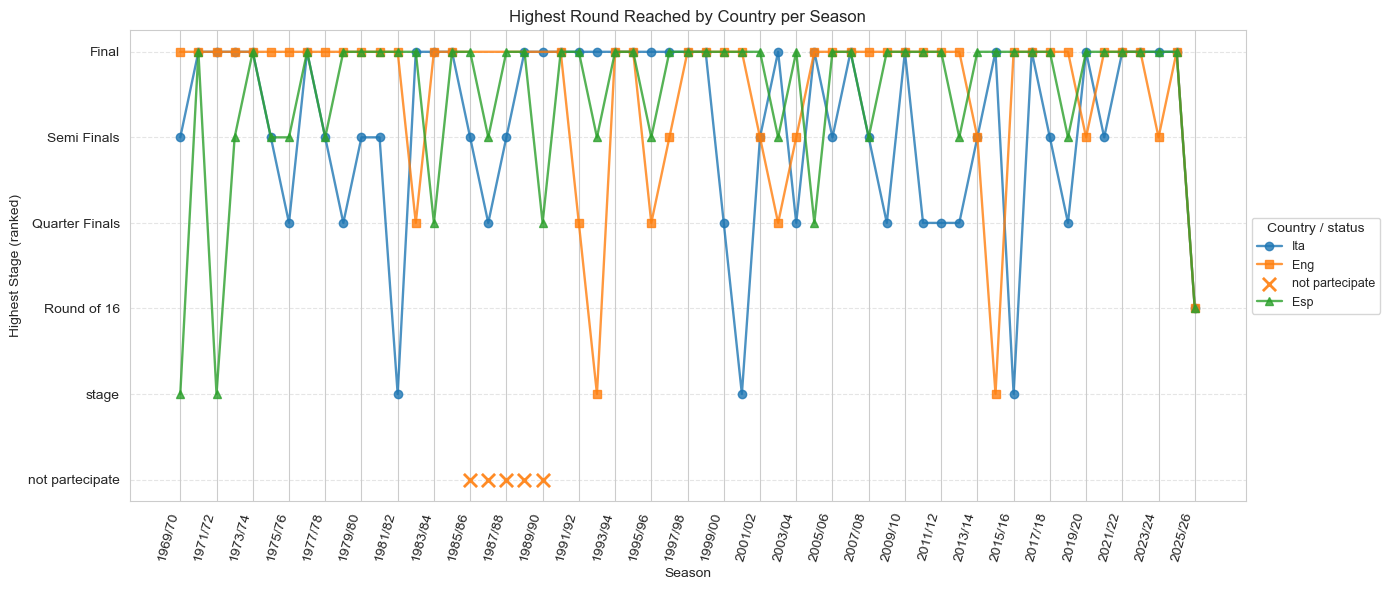

In [26]:
# Example usage:
plot_country_season_highest_round(country_season_highest, ["Ita", "Eng", "Esp"]);

### Checking Data Consistency

Running the following cells to check data consistency

In [27]:
season = ['1978/79', '1993/94']
country = 'Ita'

raw_data[(raw_data['season'].isin(season)) & ((raw_data['country_a'] == 'Ita') | (raw_data['country_b'] == 'Ita'))]

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
1126,1978/79,CL,Round 1,Juventus,Ita,Glasgow Rangers,Sco,1-0,0-2,1-2,no,no
1156,1978/79,CW,Round 1,Floriana,Mlt,Internazionale,Ita,1-3,0-5,1-8,no,no
1175,1978/79,CW,Round 2,Internazionale,Ita,Bodø/Glimt,Nor,5-0,2-1,7-1,no,no
1179,1978/79,CW,Quarter Finals,Internazionale,Ita,SK Beveren,Bel,0-0,0-1,0-1,no,no
1186,1978/79,EL,Round 1,Dukla Praha,TCH,Vicenza,Ita,1-0,1-1,2-1,no,no
1187,1978/79,EL,Round 1,AC Milan,Ita,Lokomotiva Kosice,TCH,1-0,0-1,1-1,no,no
1195,1978/79,EL,Round 1,Sporting Gijón,Esp,Torino,Ita,3-0,0-1,3-1,no,no
1214,1978/79,EL,Round 1,Dinamo Tbilisi,URS,Napoli,Ita,2-0,1-1,3-1,no,no
1233,1978/79,EL,Round 2,Levski-Spartak Sofia,Bul,AC Milan,Ita,1-1,0-3,1-4,no,no
1241,1978/79,EL,Round 3,AC Milan,Ita,Manchester City,Eng,2-2,0-3,2-5,no,no


## Additional metrics

In [28]:
country_stats.head(2)

,country,season,num_teams,wins,draws,losses,goals_for,goals_against
0,Alb,1969/70,1,0,1,1,1.0,4.0
1,Alb,1970/71,2,1,2,3,8.0,10.0


The `country_stats` dataframe contains the basic information, we now derive other metrics that might be useful in the following analysis.

This is the list of the metrics:
- `total_matches`: total number of matches played in that season
- `win_rate`: percentage of wins
- `loss_rate`: percentage of losses
- `draw_rate`: percentage of draws
- `ppg_3`: points per game considering 3 points for wins
- `ppg_2`: points per game considering 2 points for wins
- `goal_diff`: goal difference
- `gf_pg`: goal for per game
- `ga_pg`: goal against per game
- `gdpg`: goal difference per game

In [29]:
def add_derived_metrics(df: pd.DataFrame) -> pd.DataFrame:
    """
    Expand country_stats with derived performance metrics.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain: wins, draws, losses, goals_for, goals_against

    Returns
    -------
    pd.DataFrame
        Original dataframe with derived metric columns appended.
    """
    df = df.copy()

    # --- Denominator ---
    df["total_matches"] = df["wins"] + df["draws"] + df["losses"]

    # --- Rates ---
    df["win_rate"]  = df["wins"]   / df["total_matches"]
    df["draw_rate"] = df["draws"]  / df["total_matches"]
    df["loss_rate"] = df["losses"] / df["total_matches"]

    # --- Points per game ---
    df["ppg_3"] = (df["wins"] * 3 + df["draws"])     / df["total_matches"]
    df["ppg_2"] = (df["wins"] * 2 + df["draws"])     / df["total_matches"]

    # --- Goal metrics ---
    df["goal_diff"] = df["goals_for"] - df["goals_against"]
    df["gf_pg"]     = df["goals_for"]    / df["total_matches"]
    df["ga_pg"]     = df["goals_against"] / df["total_matches"]
    df["gdpg"]      = df["goal_diff"]    / df["total_matches"]

    return df

In [30]:
country_stats_complete = add_derived_metrics(country_stats)
country_stats_complete.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
0,Alb,1969/70,1,0,1,1,1.0,4.0,2,0.000000,0.500000,0.50,0.500000,0.500000,-3.0,0.500000,2.000000,-1.500000
1,Alb,1970/71,2,1,2,3,8.0,10.0,6,0.166667,0.333333,0.50,0.833333,0.666667,-2.0,1.333333,1.666667,-0.333333
2,Alb,1971/72,2,0,1,3,1.0,6.0,4,0.000000,0.250000,0.75,0.250000,0.250000,-5.0,0.250000,1.500000,-1.250000
3,Alb,1972/73,1,0,3,1,3.0,9.0,4,0.000000,0.750000,0.25,0.750000,0.750000,-6.0,0.750000,2.250000,-1.500000
4,Alb,1973/74,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [31]:
country_stats_complete[country_stats_complete['country'] == 'Eng']

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
741,Eng,1969/70,6,28,10,9,106.0,29.0,47,0.595745,0.212766,0.191489,2.000000,1.404255,77.0,2.255319,0.617021,1.638298
742,Eng,1970/71,8,33,17,11,97.0,45.0,61,0.540984,0.278689,0.180328,1.901639,1.360656,52.0,1.590164,0.737705,0.852459
743,Eng,1971/72,7,25,10,7,100.0,33.0,42,0.595238,0.238095,0.166667,2.023810,1.428571,67.0,2.380952,0.785714,1.595238
744,Eng,1972/73,6,24,8,11,70.0,32.0,43,0.558140,0.186047,0.255814,1.860465,1.302326,38.0,1.627907,0.744186,0.883721
745,Eng,1973/74,6,22,8,8,69.0,36.0,38,0.578947,0.210526,0.210526,1.947368,1.368421,33.0,1.815789,0.947368,0.868421
746,Eng,1974/75,6,12,9,4,52.0,29.0,25,0.480000,0.360000,0.160000,1.800000,1.320000,23.0,2.080000,1.160000,0.920000
747,Eng,1975/76,6,17,6,10,61.0,43.0,33,0.515152,0.181818,0.303030,1.727273,1.212121,18.0,1.848485,1.303030,0.545455
748,Eng,1976/77,6,21,1,11,86.0,37.0,33,0.636364,0.030303,0.333333,1.939394,1.303030,49.0,2.606061,1.121212,1.484848
749,Eng,1977/78,6,16,8,7,61.0,33.0,31,0.516129,0.258065,0.225806,1.806452,1.290323,28.0,1.967742,1.064516,0.903226
750,Eng,1978/79,7,23,12,8,75.0,35.0,43,0.534884,0.279070,0.186047,1.883721,1.348837,40.0,1.744186,0.813953,0.930233


In [32]:
# implement a function to plot the desired metrics for the selected countries

def plot_country_metrics(df: pd.DataFrame, countries: list,  metric: str, figsize = (12, 6)):
    '''Plot the specified metric for the given countries and seasons.
    
    Each country has a unique line marker. Where data is NaN (indicating seasons 
    where no teams from that country participated), a special 'X' marker is displayed
    to indicate missing data.
    '''
    
    # Define different markers for each country
    markers = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']
    
    # Metric descriptions for meaningful titles
    metric_descriptions = {
        'total_matches': 'Total Matches per Season',
        'win_rate': 'Win Rate (%)',
        'loss_rate': 'Loss Rate (%)',
        'draw_rate': 'Draw Rate (%)',
        'ppg_3': 'Points Per Game (3pts for Win)',
        'ppg_2': 'Points Per Game (2pts for Win)',
        'goal_diff': 'Goal Difference',
        'gf_pg': 'Goals For per Game',
        'ga_pg': 'Goals Against per Game',
        'gdpg': 'Goal Difference per Game'
    }
    
    sns.set_style("whitegrid")
    fig, ax = plt.subplots(figsize=figsize)
    
    dataset = df[df['country'].isin(countries)].copy()
    
    # Get color palette for consistent coloring
    palette = sns.color_palette("husl", len(countries))
    color_map = {country: palette[i] for i, country in enumerate(countries)}
    
    # Track if we've added the NaN label (add only once to legend)
    nan_label_added = False
    
    for i, country in enumerate(countries):
        country_data = dataset[dataset['country'] == country].sort_values('season')
        marker = markers[i % len(markers)]
        color = color_map[country]
        
        # Plot line with markers for non-NaN values (gaps appear at NaN)
        ax.plot(country_data['season'], country_data[metric], 
                marker=marker, label=country, linewidth=1.5, 
                markersize=4, color=color)
        
        # Add special 'X' markers for NaN values to indicate "no data"
        nan_mask = country_data[metric].isna()
        if nan_mask.any():
            nan_seasons = country_data.loc[nan_mask, 'season'].values
            # Position NaN markers slightly below the minimum y value
            y_min = ax.get_ylim()[0]
            nan_y = [y_min] * len(nan_seasons)
            
            ax.scatter(nan_seasons, nan_y, marker='x', s=200, 
                      color=color, linewidths=1.5, alpha=0.6, zorder=5,
                      label='No matches' if not nan_label_added else '')
            
            if not nan_label_added:
                nan_label_added = True
    
    # Adjust y-axis to accommodate NaN markers at the bottom
    y_min, y_max = ax.get_ylim()
    ax.set_ylim(y_min - (y_max - y_min) * 0.12, y_max)
    
    # Use descriptive title if metric is in the descriptions dictionary
    metric_title = metric_descriptions.get(metric, metric)
    
    plt.xticks(rotation=70)
    plt.title(f"{metric_title} by Country over Seasons")
    plt.xlabel("Season")
    plt.ylabel(metric_title)
    plt.legend(title='Country', fontsize=9)
    plt.tight_layout()
    plt.show()

In [52]:
country_stats_complete.columns

Index(['country', 'season', 'num_teams', 'wins', 'draws', 'losses',
       'goals_for', 'goals_against', 'total_matches', 'win_rate', 'draw_rate',
       'loss_rate', 'ppg_3', 'ppg_2', 'goal_diff', 'gf_pg', 'ga_pg', 'gdpg'],
      dtype='str')

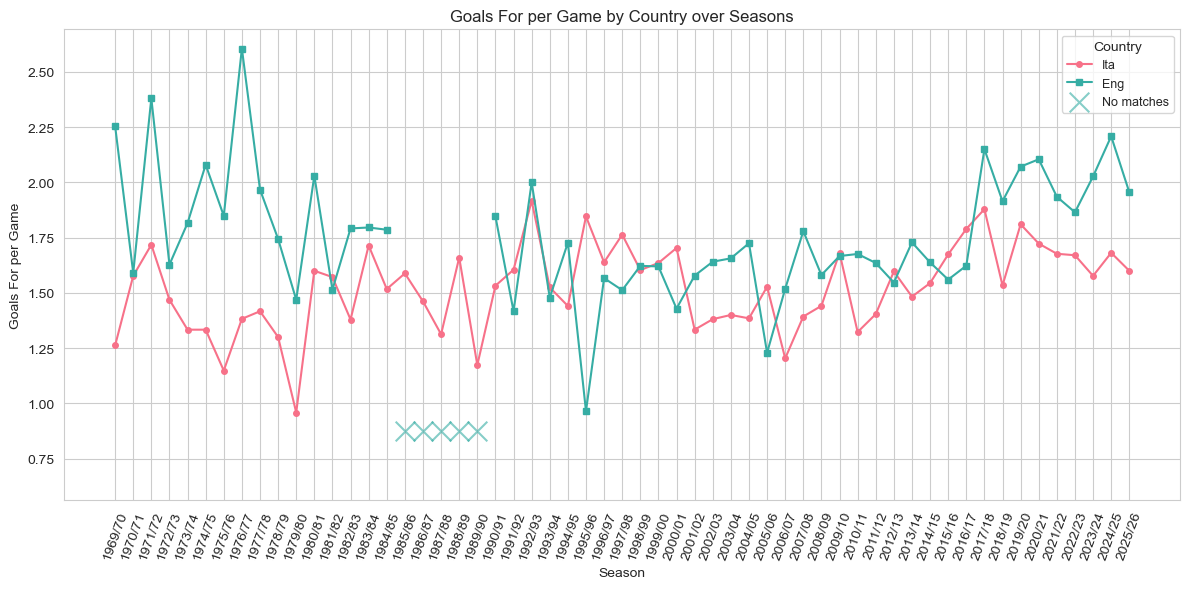

In [55]:
plot_country_metrics(country_stats_complete, countries=['Ita', 'Eng'], metric='gf_pg')

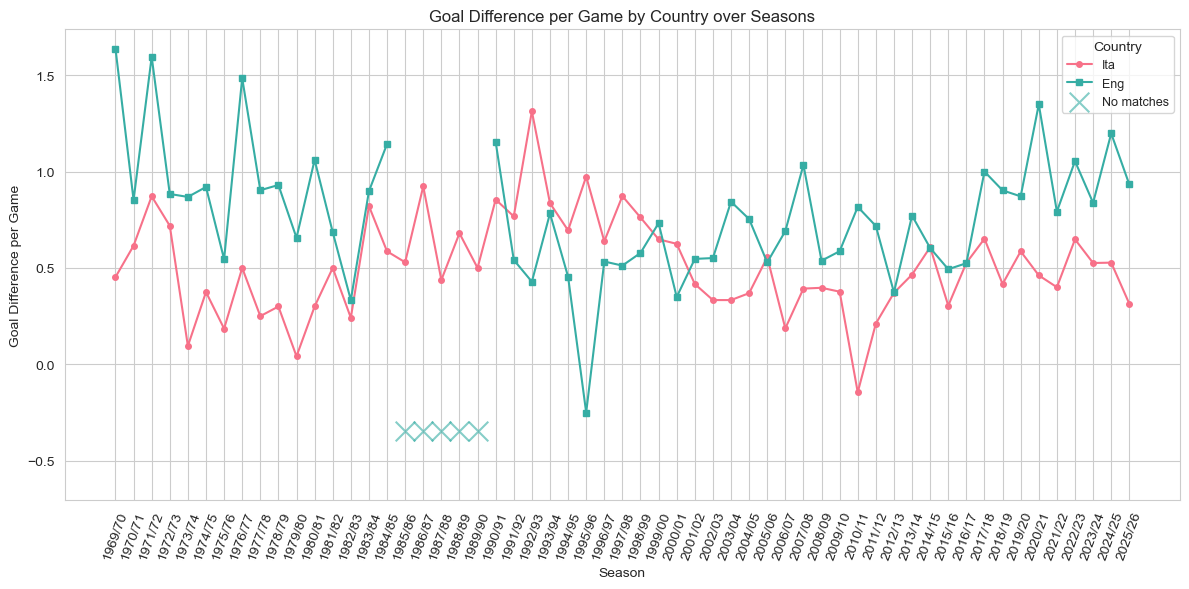

In [34]:
plot_country_metrics(country_stats_complete, countries=['Ita','Eng'], metric='gdpg')

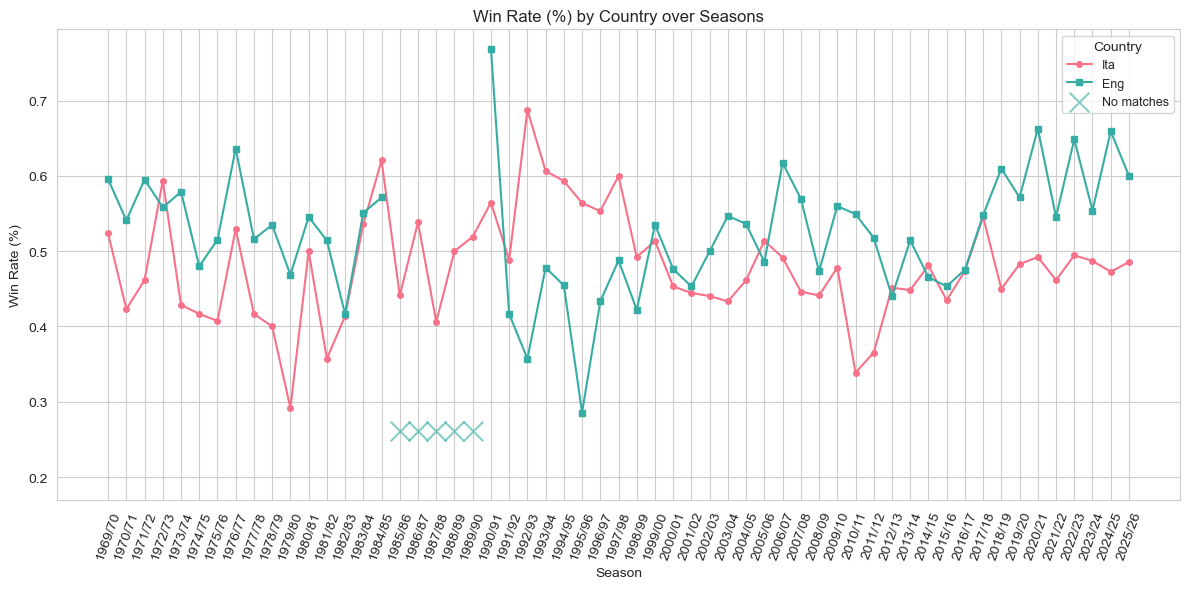

In [59]:
plot_country_metrics(country_stats_complete, countries=['Ita', 'Eng'], metric='win_rate')

In [60]:
country_stats_complete[(country_stats_complete['country'] == 'Eng') &
                       (country_stats_complete['season'].isin(['1995/96']))]

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
767,Eng,1995/96,6,8,8,12,27.0,34.0,28,0.285714,0.285714,0.428571,1.142857,0.857143,-7.0,0.964286,1.214286,-0.25


In [61]:
get_countries_seasons_details(raw_data, ['1995/96'], ['Eng'])

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties,era
3370,1995/96,CL,Group Stage,Blackburn Rovers,Eng,Spartak Moscow,Rus,0-1,0-3,0-4,no,no,Golden Era
3372,1995/96,CL,Group Stage,Rosenborg BK,Nor,Blackburn Rovers,Eng,2-1,1-4,3-5,no,no,Golden Era
3373,1995/96,CL,Group Stage,Legia Warsaw,Pol,Blackburn Rovers,Eng,1-0,0-0,1-0,no,no,Golden Era
3412,1995/96,CW,Round 1,KR Reykjavik,Isl,Everton,Eng,2-3,1-3,3-6,no,no,Golden Era
3427,1995/96,CW,Round 2,Everton,Eng,Feyenoord,Ned,0-0,0-1,0-1,no,no,Golden Era
3476,1995/96,EL,Round 1,Rotor Volgograd,Rus,Manchester United,Eng,0-0,2-2,2-2,no,no,Golden Era
3494,1995/96,EL,Round 1,Malmö FF,Swe,Nottingham Forest,Eng,2-1,0-1,2-2,no,no,Golden Era
3496,1995/96,EL,Round 1,AS Monaco,Fra,Leeds United,Eng,0-3,1-0,1-3,no,no,Golden Era
3502,1995/96,EL,Round 1,Alania Vladikavkaz,Rus,Liverpool,Eng,1-2,0-0,1-2,no,no,Golden Era
3505,1995/96,EL,Round 2,Brøndby IF,Den,Liverpool,Eng,0-0,1-0,1-0,no,no,Golden Era


In [35]:
country_stats_complete.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
0,Alb,1969/70,1,0,1,1,1.0,4.0,2,0.000000,0.500000,0.50,0.500000,0.500000,-3.0,0.500000,2.000000,-1.500000
1,Alb,1970/71,2,1,2,3,8.0,10.0,6,0.166667,0.333333,0.50,0.833333,0.666667,-2.0,1.333333,1.666667,-0.333333
2,Alb,1971/72,2,0,1,3,1.0,6.0,4,0.000000,0.250000,0.75,0.250000,0.250000,-5.0,0.250000,1.500000,-1.250000
3,Alb,1972/73,1,0,3,1,3.0,9.0,4,0.000000,0.750000,0.25,0.750000,0.750000,-6.0,0.750000,2.250000,-1.500000
4,Alb,1973/74,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


In [36]:
get_countries_seasons_details(raw_data, ['1995/96'], ['Eng'])   

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
3370,1995/96,CL,Group Stage,Blackburn Rovers,Eng,Spartak Moscow,Rus,0-1,0-3,0-4,no,no
3372,1995/96,CL,Group Stage,Rosenborg BK,Nor,Blackburn Rovers,Eng,2-1,1-4,3-5,no,no
3373,1995/96,CL,Group Stage,Legia Warsaw,Pol,Blackburn Rovers,Eng,1-0,0-0,1-0,no,no
3412,1995/96,CW,Round 1,KR Reykjavik,Isl,Everton,Eng,2-3,1-3,3-6,no,no
3427,1995/96,CW,Round 2,Everton,Eng,Feyenoord,Ned,0-0,0-1,0-1,no,no
3476,1995/96,EL,Round 1,Rotor Volgograd,Rus,Manchester United,Eng,0-0,2-2,2-2,no,no
3494,1995/96,EL,Round 1,Malmö FF,Swe,Nottingham Forest,Eng,2-1,0-1,2-2,no,no
3496,1995/96,EL,Round 1,AS Monaco,Fra,Leeds United,Eng,0-3,1-0,1-3,no,no
3502,1995/96,EL,Round 1,Alania Vladikavkaz,Rus,Liverpool,Eng,1-2,0-0,1-2,no,no
3505,1995/96,EL,Round 2,Brøndby IF,Den,Liverpool,Eng,0-0,1-0,1-0,no,no


In [37]:
get_countries_seasons_details(raw_data, ['2020/21'], ['Eng'])   

,season,competition,round,team_a,country_a,team_b,country_b,score_leg1,score_leg2,score_aggregate,extra_time,penalties
11002,2020/21,CL,Group Stage,Manchester City,Eng,FC Porto,Por,3-1,0-0,3-1,no,no
11004,2020/21,CL,Group Stage,Olympique Marseille,Fra,Manchester City,Eng,0-3,0-3,0-6,no,no
11007,2020/21,CL,Group Stage,Manchester City,Eng,Olympiakos Piraeus,Gre,3-0,1-0,4-0,no,no
11009,2020/21,CL,Group Stage,Ajax,Ned,Liverpool,Eng,0-1,0-1,0-2,no,no
11010,2020/21,CL,Group Stage,Liverpool,Eng,FC Midtjylland,Den,2-0,1-1,3-1,no,no
11012,2020/21,CL,Group Stage,Atalanta,Ita,Liverpool,Eng,0-5,2-0,2-5,no,no
11014,2020/21,CL,Group Stage,Chelsea,Eng,Sevilla,Esp,0-0,4-0,4-0,no,no
11016,2020/21,CL,Group Stage,FK Krasnodar,Rus,Chelsea,Eng,0-4,1-1,1-5,no,no
11019,2020/21,CL,Group Stage,Chelsea,Eng,Stade Rennais,Fra,3-0,2-1,5-1,no,no
11033,2020/21,CL,Group Stage,Paris Saint-Germain,Fra,Manchester United,Eng,1-2,3-1,4-3,no,no


## Analysis-Ready dataset 

In [38]:
country_stats_complete.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against,total_matches,win_rate,draw_rate,loss_rate,ppg_3,ppg_2,goal_diff,gf_pg,ga_pg,gdpg
0,Alb,1969/70,1,0,1,1,1.0,4.0,2,0.000000,0.500000,0.50,0.500000,0.500000,-3.0,0.500000,2.000000,-1.500000
1,Alb,1970/71,2,1,2,3,8.0,10.0,6,0.166667,0.333333,0.50,0.833333,0.666667,-2.0,1.333333,1.666667,-0.333333
2,Alb,1971/72,2,0,1,3,1.0,6.0,4,0.000000,0.250000,0.75,0.250000,0.250000,-5.0,0.250000,1.500000,-1.250000
3,Alb,1972/73,1,0,3,1,3.0,9.0,4,0.000000,0.750000,0.25,0.750000,0.750000,-6.0,0.750000,2.250000,-1.500000
4,Alb,1973/74,0,0,0,0,0.0,0.0,0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN


This is a list of the analysis-ready datasets we produced from the wrangling analysis



In [39]:
country_stats.head()

,country,season,num_teams,wins,draws,losses,goals_for,goals_against
0,Alb,1969/70,1,0,1,1,1.0,4.0
1,Alb,1970/71,2,1,2,3,8.0,10.0
2,Alb,1971/72,2,0,1,3,1.0,6.0
3,Alb,1972/73,1,0,3,1,3.0,9.0
4,Alb,1973/74,0,0,0,0,0.0,0.0


In [40]:
country_stats_complete.columns

Index(['country', 'season', 'num_teams', 'wins', 'draws', 'losses',
       'goals_for', 'goals_against', 'total_matches', 'win_rate', 'draw_rate',
       'loss_rate', 'ppg_3', 'ppg_2', 'goal_diff', 'gf_pg', 'ga_pg', 'gdpg'],
      dtype='str')

In [41]:
country_stats_complete.dtypes

country              str
season               str
num_teams          int64
wins               int64
draws              int64
losses             int64
goals_for        float64
goals_against    float64
total_matches      int64
win_rate         float64
draw_rate        float64
loss_rate        float64
ppg_3            float64
ppg_2            float64
goal_diff        float64
gf_pg            float64
ga_pg            float64
gdpg             float64
dtype: object

In [42]:
country_season_competition_highest.columns

Index(['season', 'country', 'competition', 'highest_round'], dtype='str')

In [43]:
country_season_competition_highest['competition'].unique()

<StringArray>
['CL', 'CO', 'CW', 'EL', 'INTER-CITIES FAIRS CUP']
Length: 5, dtype: str

In [44]:
raw_data.columns

Index(['season', 'competition', 'round', 'team_a', 'country_a', 'team_b',
       'country_b', 'score_leg1', 'score_leg2', 'score_aggregate',
       'extra_time', 'penalties'],
      dtype='str')

In [45]:
# save processed data for later use in analysis and visualization
raw_data.to_pickle('../data/processed/raw_data.pkl')
country_stats_complete.to_pickle('../data/processed/country_stats_complete.pkl')
country_season_highest.to_pickle('../data/processed/country_season_highest.pkl')
country_season_competition_highest.to_pickle('../data/processed/country_season_competition_highest.pkl')    


## Building the Golden Era Dataset

In the analysis, I will make an hypothesis, based more on public perception, about an Italian Club Golden era. To make the appropriate analysis, I need to implement functions that will add a column to the dataset marking the pre, during and post golden era.   

In [46]:
"""
Step 0 · Era labelling
─────────────────────
Provides a single entry point:

    add_era_column(df, season_col, golden_start, golden_end)

which adds an 'era' column to any of the four DataFrames.

Era logic
─────────
A season string  '2002/03'  is parsed by its START year (2002).
  start_year  <  golden_start_year   →  'Pre-Golden Era'
  start_year  <= golden_end_year     →  'Golden Era'
  start_year  >  golden_end_year     →  'Post-Golden Era'

Default golden era: 1987/88 – 2003/04  (change via the two parameters).
"""

import pandas as pd

# ── Era labels (single source of truth) ──────────────────────────────────────
ERA_PRE    = "Pre-Golden Era"
ERA_GOLDEN = "Golden Era"
ERA_POST   = "Post-Golden Era"

# Ordered list – useful for sorting / CategoricalDtype later
ERA_ORDER = [ERA_PRE, ERA_GOLDEN, ERA_POST]


# ── Core helpers ─────────────────────────────────────────────────────────────

def _season_to_start_year(season: str) -> int | None:
    """
    Parse the start year from a season string.

    Handles the two common formats:
      '2002/03'  →  2002
      '2002-03'  →  2002

    Returns None if the season string cannot be parsed (allows the caller
    to decide how to handle bad data rather than raising silently).
    """
    if not isinstance(season, str):
        return None
    # Accept both '/' and '-' separators
    for sep in ("/", "-"):
        if sep in season:
            try:
                return int(season.split(sep)[0].strip())
            except ValueError:
                return None
    # Fallback: maybe it's just a plain year string e.g. '2002'
    try:
        return int(season.strip())
    except ValueError:
        return None


def _classify_era(season: str,
                  golden_start_year: int,
                  golden_end_year: int) -> str:
    """
    Return the era label for a single season string.
    Unparseable seasons get ERA_PRE as a safe default (will show up in the
    null/coverage report in later steps).
    """
    start_year = _season_to_start_year(season)
    if start_year is None:
        return ERA_PRE          # flag as early; easy to spot in QA

    if start_year < golden_start_year:
        return ERA_PRE
    elif start_year <= golden_end_year:
        return ERA_GOLDEN
    else:
        return ERA_POST


# ── Public API ────────────────────────────────────────────────────────────────

def add_era_column(
    df: pd.DataFrame,
    season_col: str = "season",
    golden_start: str = "1987/88",
    golden_end:   str = "2003/04",
    era_col:      str = "era",
) -> pd.DataFrame:
    """
    Add an 'era' column to *df* and return the enriched DataFrame.

    Parameters
    ----------
    df            : any of the four input DataFrames
    season_col    : name of the column that holds season strings (default 'season')
    golden_start  : first season of the Golden Era  (default '1987/88')
    golden_end    : last  season of the Golden Era  (default '2003/04')
    era_col       : name of the new column          (default 'era')

    Returns
    -------
    A copy of *df* with the new era column appended.
    The column is typed as an ordered Categorical so that
    groupby / sort operations respect the natural era sequence.

    Example
    -------
    >>> cs = add_era_column(country_stats, golden_start="1987/88", golden_end="2003/04")
    >>> cs["era"].value_counts()
    """
    # Parse boundary years once (fail fast if caller passes garbage)
    golden_start_year = _season_to_start_year(golden_start)
    golden_end_year   = _season_to_start_year(golden_end)

    if golden_start_year is None or golden_end_year is None:
        raise ValueError(
            f"Could not parse golden_start='{golden_start}' or "
            f"golden_end='{golden_end}'. "
            "Expected format: 'YYYY/YY'  e.g. '1987/88'."
        )
    if golden_start_year > golden_end_year:
        raise ValueError(
            f"golden_start ({golden_start}) must be before "
            f"golden_end ({golden_end})."
        )

    out = df.copy()

    if season_col not in out.columns:
        raise KeyError(
            f"Column '{season_col}' not found in DataFrame. "
            f"Available columns: {list(out.columns)}"
        )

    out[era_col] = out[season_col].apply(
        lambda s: _classify_era(s, golden_start_year, golden_end_year)
    )

    # Make it an ordered Categorical – preserves sort order in groupby outputs
    out[era_col] = pd.Categorical(out[era_col],
                                  categories=ERA_ORDER,
                                  ordered=True)

    return out


# ── Convenience wrapper: apply to all four DataFrames in one call ─────────────

def add_era_to_all(
    raw_data,
    country_stats,
    country_season_highest,
    country_season_competition_highest,
    golden_start: str = "1987/88",
    golden_end:   str = "2003/04",
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Apply add_era_column to all four DataFrames and return enriched copies.

    Usage
    -----
    rd, cs, csh, csch = add_era_to_all(
        raw_data, country_stats,
        country_season_highest, country_season_competition_highest,
        golden_start="1987/88", golden_end="2003/04",
    )
    """
    kwargs = dict(golden_start=golden_start, golden_end=golden_end)

    rd   = add_era_column(raw_data,                          **kwargs)
    cs   = add_era_column(country_stats,                     **kwargs)
    csh  = add_era_column(country_season_highest,            **kwargs)
    csch = add_era_column(country_season_competition_highest,**kwargs)

    _print_era_summary(cs, golden_start, golden_end)

    return rd, cs, csh, csch


# ── QA helper ────────────────────────────────────────────────────────────────

def _print_era_summary(cs: pd.DataFrame,
                       golden_start: str,
                       golden_end: str) -> None:
    """Print a quick sanity-check table after labelling."""
    print(f"\n  Era definition : {golden_start}  →  {golden_end}")
    print(f"  {'Era':<22}  {'Seasons':>7}  {'First':>9}  {'Last':>9}")
    print("  " + "-" * 52)
    for era in ERA_ORDER:
        sub = cs[cs["era"] == era]
        if sub.empty:
            print(f"  {era:<22}  {'0':>7}  {'—':>9}  {'—':>9}")
        else:
            seasons = sorted(sub["season"].unique(),
                             key=lambda s: _season_to_start_year(s) or 0)
            print(f"  {era:<22}  {len(seasons):>7}  "
                  f"{seasons[0]:>9}  {seasons[-1]:>9}")
    print()

In [47]:
raw_data['round'].unique()

<StringArray>
[                'Qualifying Round',                          'Round 1',
                          'Round 2',                   'Quarter Finals',
                      'Semi Finals',                            'Final',
                          'Round 3',                      'Group Stage',
             '1st Qualifying Round',             '2nd Qualifying Round',
             '3rd Qualifying Round',                  '1st Group Stage',
                  '2nd Group Stage',                          'Round 4',
 '4th Qualifying or Play-off Round',        'Qualifying Play-off Round',
                'Preliminary Round',                      'Round of 16',
         'Knockout round play-offs',                     'League Stage']
Length: 20, dtype: str

In [48]:
raw_data, country_stats, country_season_highest, country_season_competition_highest = add_era_to_all(
    raw_data, 
    country_stats,
    country_season_highest, 
    country_season_competition_highest,
    golden_start="1987/88",
    golden_end="2003/04",
)


  Era definition : 1987/88  →  2003/04
  Era                     Seasons      First       Last
  ----------------------------------------------------
  Pre-Golden Era               18    1969/70    1986/87
  Golden Era                   17    1987/88    2003/04
  Post-Golden Era              22    2004/05    2025/26



### Stage grouping in `raw_data` dataset

As we already implemented for the dataset that checked the highest round reached in every competition by team belonging to a country, we add now a column to the `raw_data` dataset indicating the stage the match belongs to. By doing it, we introduce an ordering (a hierarchy) in the group stages

*'stage'  <  'Round of 16'  <  'Quarter Finals'  <  'Semi Finals'  <  'Final'*

Where `stage` referst to all rounds about Round of 16. The result is stored in a new column `round_group` typed as an ordered Categorical so that comparisons like
```python
    df['round_group'] >= 'Quarter Finals'
```

and groupby / sort operations work correctly out of the box.

> NOTE: `country_season_highest` and `country_season_competition_highest` already carry the grouped label in `highest_round` — no mapping or ordering is applied to those DataFrames here.

In [5]:
import pandas as pd

# ── Ordered group labels (single source of truth) ─────────────────────────────
ROUND_GROUPS = ["stage", "Round of 16", "Quarter Finals", "Semi Finals", "Final"]

# ── Exhaustive mapping: raw label → group ─────────────────────────────────────
# Every value found in raw_data['round'] that belongs to 'stage'.
# Knockout rounds map to themselves.
_ROUND_MAP: dict[str, str] = {
    # ── 'stage' bucket ────────────────────────────────────────────────────────
    "Qualifying Round"                  : "stage",
    "1st Qualifying Round"              : "stage",
    "2nd Qualifying Round"              : "stage",
    "3rd Qualifying Round"              : "stage",
    "4th Qualifying or Play-off Round"  : "stage",
    "Qualifying Play-off Round"         : "stage",
    "Preliminary Round"                 : "stage",
    "Round 1"                           : "stage",
    "Round 2"                           : "stage",
    "Round 3"                           : "stage",
    "Round 4"                           : "stage",
    "Group Stage"                       : "stage",
    "1st Group Stage"                   : "stage",
    "2nd Group Stage"                   : "stage",
    "Knockout round play-offs"          : "stage",
    "League Stage"                      : "stage",
    # ── Knockout rounds (map to themselves) ───────────────────────────────────
    "Round of 16"                       : "Round of 16",
    "Quarter Finals"                    : "Quarter Finals",
    "Semi Finals"                       : "Semi Finals",
    "Final"                             : "Final",
}


# ── Core function ─────────────────────────────────────────────────────────────

def add_round_group(
    df: pd.DataFrame,
    round_col:  str = "round",
    output_col: str = "round_group",
) -> pd.DataFrame:
    """
    Add a 'round_group' column to raw_data.

    Parameters
    ----------
    df         : raw_data DataFrame
    round_col  : name of the column that holds the raw round strings
    output_col : name of the new grouped column  (default 'round_group')

    Returns
    -------
    A copy of df with the new column appended as an ordered Categorical:
        'stage' < 'Round of 16' < 'Quarter Finals' < 'Semi Finals' < 'Final'

    Unmapped round strings are set to NaN and reported so you can extend
    _ROUND_MAP without silent data loss.
    """
    if round_col not in df.columns:
        raise KeyError(
            f"Column '{round_col}' not found. "
            f"Available columns: {list(df.columns)}"
        )

    out = df.copy()
    out[output_col] = out[round_col].map(_ROUND_MAP)

    # ── QA: report any unmapped values ───────────────────────────────────────
    unmapped_mask = out[output_col].isna() & out[round_col].notna()
    if unmapped_mask.any():
        unmapped_vals = out.loc[unmapped_mask, round_col].value_counts()
        print(f"\n  [round_group] WARNING – {unmapped_mask.sum()} unmapped rows "
              f"({unmapped_vals.shape[0]} distinct label(s)):")
        for label, count in unmapped_vals.items():
            print(f"    '{label}'  →  {count} rows  "
                  f"(add to _ROUND_MAP in step0_round.py)")
    else:
        print(f"\n  [round_group] All round labels mapped successfully "
              f"({out[output_col].notna().sum()} / {len(out)} rows).")

    # ── Apply ordered Categorical ─────────────────────────────────────────────
    out[output_col] = pd.Categorical(
        out[output_col],
        categories=ROUND_GROUPS,
        ordered=True,
    )

    return out


# ── Quick-look helper ─────────────────────────────────────────────────────────

def round_group_summary(df: pd.DataFrame, round_group_col: str = "round_group") -> None:
    """
    Print a distribution table of the round_group column.
    Useful for a fast sanity check after calling add_round_group().
    """
    if round_group_col not in df.columns:
        print(f"  Column '{round_group_col}' not found — run add_round_group() first.")
        return

    counts = (df[round_group_col]
              .value_counts()
              .reindex(ROUND_GROUPS, fill_value=0))
    total  = counts.sum()

    print(f"\n  {'Round group':<20}  {'Count':>7}  {'%':>6}")
    print("  " + "-" * 38)
    for group, count in counts.items():
        pct = 100 * count / total if total else 0
        print(f"  {group:<20}  {count:>7,}  {pct:>5.1f}%")
    print(f"  {'TOTAL':<20}  {total:>7,}  100.0%\n")

In [6]:
# Round grouping on raw_data only
raw_data = add_round_group(raw_data)
round_group_summary(raw_data) 


  [round_group] All round labels mapped successfully (13872 / 13872 rows).

  Round group             Count       %
  --------------------------------------
  stage                  12,747   91.9%
  Round of 16               119    0.9%
  Quarter Finals            572    4.1%
  Semi Finals               288    2.1%
  Final                     146    1.1%
  TOTAL                  13,872  100.0%

